In [ ]:
# Controlled Synthetic Ecosystems
# Motivation
# This experiment isolates the mechanism of budgeted nonlinear substitution under an honest fit/eval split. We compare a convex baseline and kernelized substitution under two regimes: convex-compatible targets and nonlinear RKHS targets.  
# $$
# U_t^{\mathrm{ker}}(\Lambda)=\mathbb{E}_{(x,\theta)\in P_{\mathrm{eval}}}\left[\left|Y_t-h^*_{\Lambda}(\Phi_{-t})\right|\right],\quad
# U_t^{\mathrm{conv}}=\mathbb{E}\left[\left|Y_t-\sum_j\hat w_jY_j\right|\right].
# $$
# Define budget revenue $\Delta_t(\Lambda)=U_t^{\mathrm{conv}}-U_t^{\mathrm{ker}}(\Lambda)$，where $\Lambda\propto 1/\lambda$。
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "legend.frameon": False,
    "figure.figsize": (7, 4.5),
    "figure.dpi": 150,
    "mathtext.fontset": "dejavuserif"
})

from pathlib import Path
import numpy as np
import pandas as pd
art_dir = Path('../results/artifacts').resolve()
art_dir.mkdir(parents=True, exist_ok=True)
csv_path = Path('../results/tables/exp1_synthetic_kernel.csv').resolve()
df = pd.read_csv(csv_path)
df.head()

,seed,condition,method,lambda,budget,pier_score,n_fit,n_eval,n_peers,kernel_type,gamma,honesty_fit_size,honesty_eval_size
0,0,A_ConvexHull,ConvexDISCO,0.000001,1000000.000000,0.002510,240,320,8,rbf,0.033676,240,320
1,0,A_ConvexHull,KernelDISCO,0.000001,1000000.000000,0.011734,240,320,8,rbf,0.033676,240,320
2,0,A_ConvexHull,ConvexDISCO,0.000003,333333.333333,0.002510,240,320,8,rbf,0.033676,240,320
3,0,A_ConvexHull,KernelDISCO,0.000003,333333.333333,0.011690,240,320,8,rbf,0.033676,240,320
4,0,A_ConvexHull,ConvexDISCO,0.000010,100000.000000,0.002510,240,320,8,rbf,0.033676,240,320


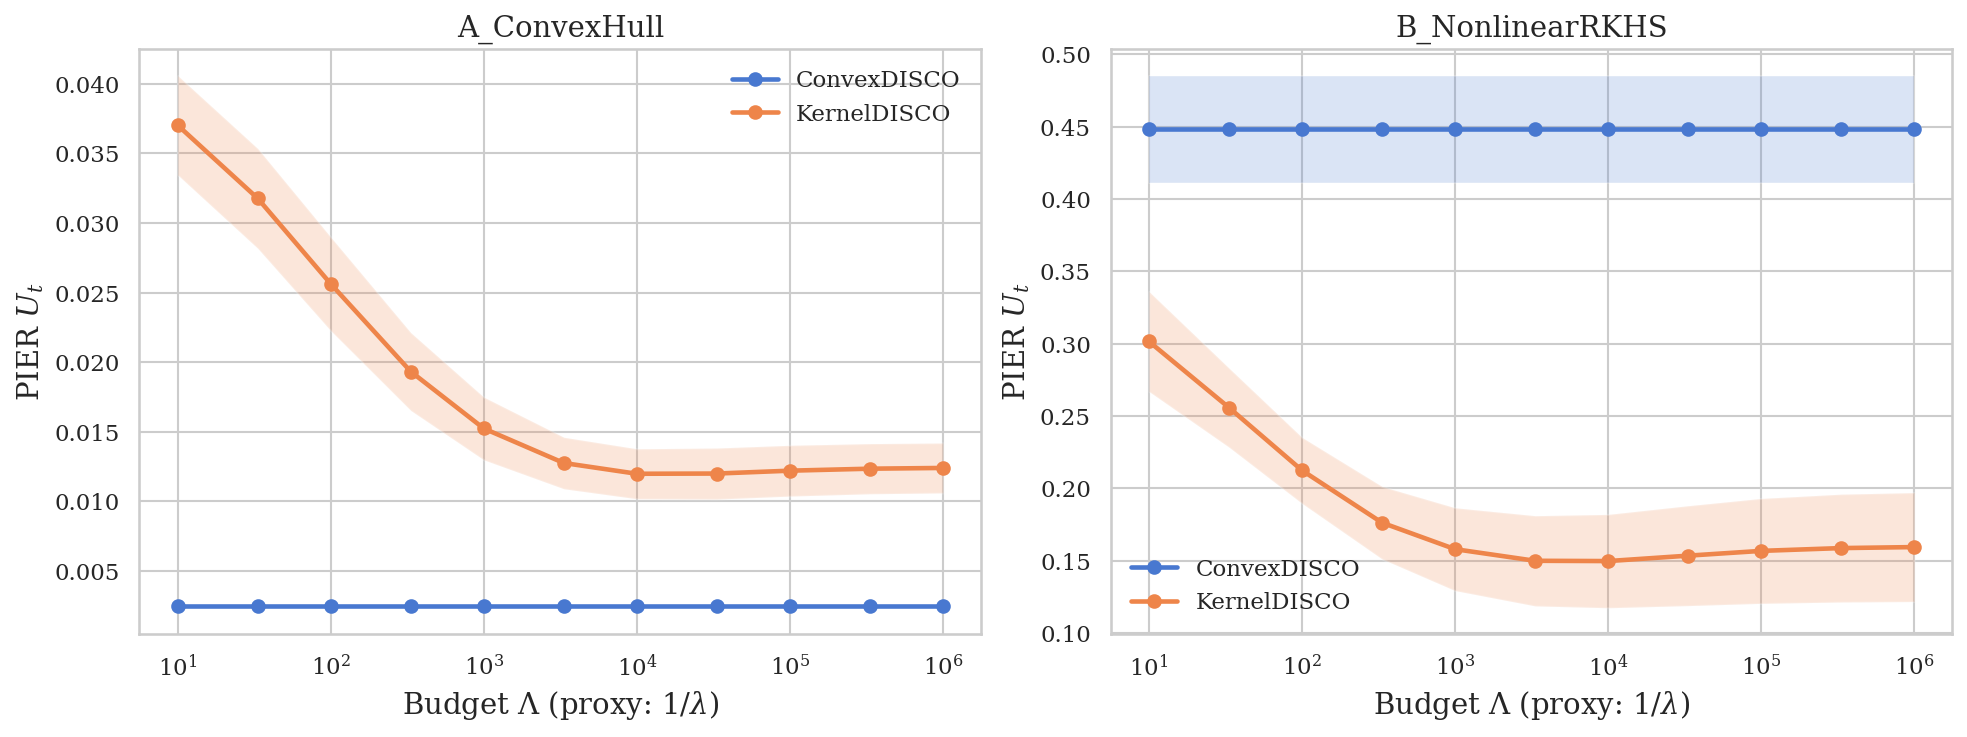

In [ ]:
# Budget-response is the primary mechanistic claim
# We first reproduce the core budget curve with uncertainty bands across seeds, 
# which is the central evidence for nonlinear substitution gains.
agg = (
    df.groupby(['condition', 'method', 'budget'], as_index=False)
    .agg(pier_mean=('pier_score', 'mean'), pier_std=('pier_score', 'std'))
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
for ax, cond in zip(axes, ['A_ConvexHull', 'B_NonlinearRKHS']):
    sub = agg[agg['condition'] == cond]
    for method in ['ConvexDISCO', 'KernelDISCO']:
        m = sub[sub['method'] == method].sort_values('budget')
        x = m['budget'].to_numpy()
        mu = m['pier_mean'].to_numpy()
        sd = m['pier_std'].fillna(0.0).to_numpy()
        ax.plot(x, mu, marker='o', linewidth=2.2, label=method)
        ax.fill_between(x, mu - sd, mu + sd, alpha=0.2)
    ax.set_xscale('log')
    ax.set_xlabel(r'Budget $\Lambda$ (proxy: $1/\lambda$)')
    ax.set_ylabel(r'PIER $U_t$')
    ax.set_title(cond)
    ax.legend(loc='best')

plt.savefig(art_dir / 'exp1_main_budget_curve.pdf', format='pdf', bbox_inches='tight')
plt.show()

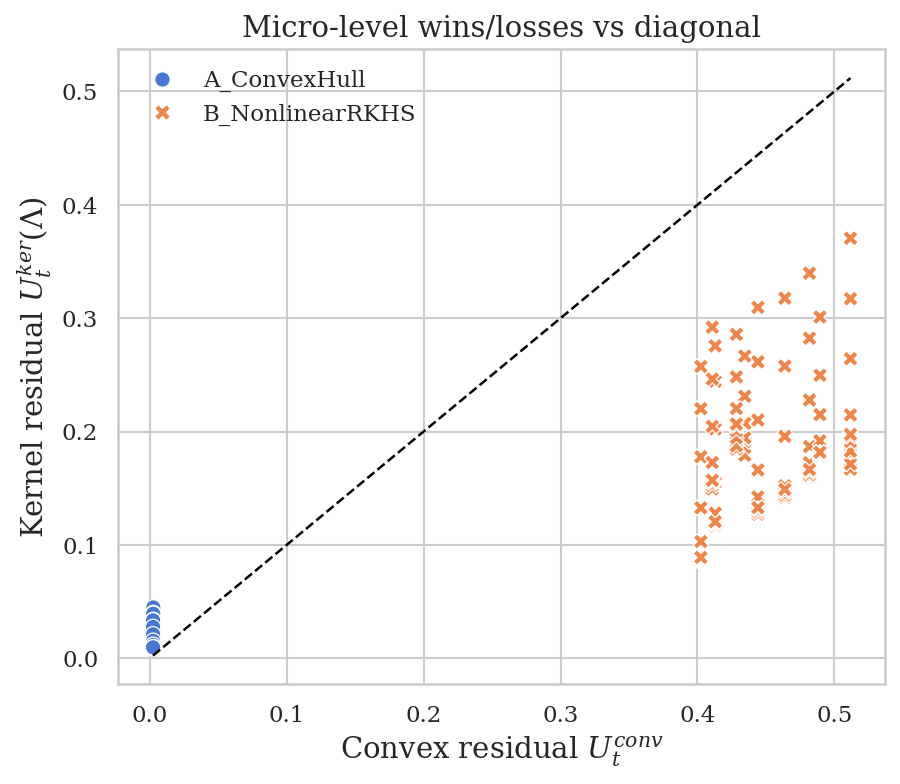

In [20]:
##Micro-level pairwise comparison (Convex vs Kernel)
##A direct scatter against the diagonal reveals exactly where kernel substitution wins (y<x) or fails (y>x).
pivot_gain = (
    df.pivot_table(index=['seed', 'condition', 'budget'], columns='method', values='pier_score')
    .reset_index()
)
sc = pivot_gain.copy()
fig, ax = plt.subplots(figsize=(6.6, 5.5))
sns.scatterplot(data=sc, x='ConvexDISCO', y='KernelDISCO', hue='condition', style='condition', s=55, ax=ax)
mn = min(sc['ConvexDISCO'].min(), sc['KernelDISCO'].min())
mx = max(sc['ConvexDISCO'].max(), sc['KernelDISCO'].max())
ax.plot([mn, mx], [mn, mx], linestyle='--', color='black', linewidth=1.2)
ax.set_xlabel(r'Convex residual $U_t^{conv}$')
ax.set_ylabel(r'Kernel residual $U_t^{ker}(\Lambda)$')
ax.set_title('Micro-level wins/losses vs diagonal')
ax.legend(loc='best')
plt.savefig(art_dir / 'exp1_micro_scatter_convex_vs_kernel.pdf', format='pdf', bbox_inches='tight')
plt.show()